In [1]:
excelpath = "../Excel_files"
figpath = "../figs"
fig_prefix = "Dickman_etal_Results"
excelfile = "fig6.xlsx"

# Run this cell, then comment out the lines below and restart the kernel.
# import os
# !yes | neuronpyxl -f gen_mods --file {os.path.join(excelpath,excelfile)}

In [2]:
import sys
import os
sys.path.append("../")
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
import numpy as np
from neuronpyxl import network
from scipy.interpolate import griddata
plt.style.use(["no-latex", "notebook"])

In [2]:
def remove_axes(ax,remove_x=True,remove_y=False):
    # For aesthetics
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if remove_x:
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
    if remove_y:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        
def plot_vertical_scalebar(ax,scalebar_length=20,bar_width=0.25,offset=0,xoffset=1,yoffset=10):
    from matplotlib.patches import Rectangle
    # Get axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Coordinates for bottom-right corner
    x_start = xlim[1] - offset - bar_width
    y_start = ylim[0] + yoffset

    scalebar = Rectangle((x_start, y_start), width=bar_width, height=scalebar_length,
                        color='black', linewidth=0, zorder=10)

    ax.add_patch(scalebar)

    # Optional: Add text label
    ax.text(x_start-xoffset, y_start + scalebar_length / 2, f'{scalebar_length} mV',
            va='center', ha='right', color='black', fontsize=16)

In [3]:
nb1 = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="synapse",
                            noise=None,dt=-1,integrator=2,atol=1e-5,eq_time=1000,simdur=9000,seed=False)

Added Cell(gid=1, name=A) to the network.
Added Cell(gid=2, name=B) to the network.
Loading simulation parameters...


In [4]:
g = 0.05
nb1.electrical_synapses["A"]["B"].g = g
nb1.electrical_synapses["B"]["A"].g = g
nb1.run()
A1 = nb1.get_cell_data("A")
B1 = nb1.get_cell_data("B")

g = 0.1
nb1.electrical_synapses["A"]["B"].g = g
nb1.electrical_synapses["B"]["A"].g = g
nb1.run()
A2 = nb1.get_cell_data("A")
B2 = nb1.get_cell_data("B")

Running simulation...
Running simulation...


In [5]:
nb2 = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="synapse2",
                            noise=None,dt=-1,integrator=2,atol=1e-5,eq_time=1000,simdur=9000,seed=False)

Added Cell(gid=3, name=A) to the network.
Added Cell(gid=4, name=B) to the network.
Loading simulation parameters...


In [6]:
g = 0.04
nb2.electrical_synapses["A"]["B"].g = g
nb2.electrical_synapses["B"]["A"].g = g
nb2.run()
A3 = nb2.get_cell_data("A")
B3 = nb2.get_cell_data("B")

Running simulation...


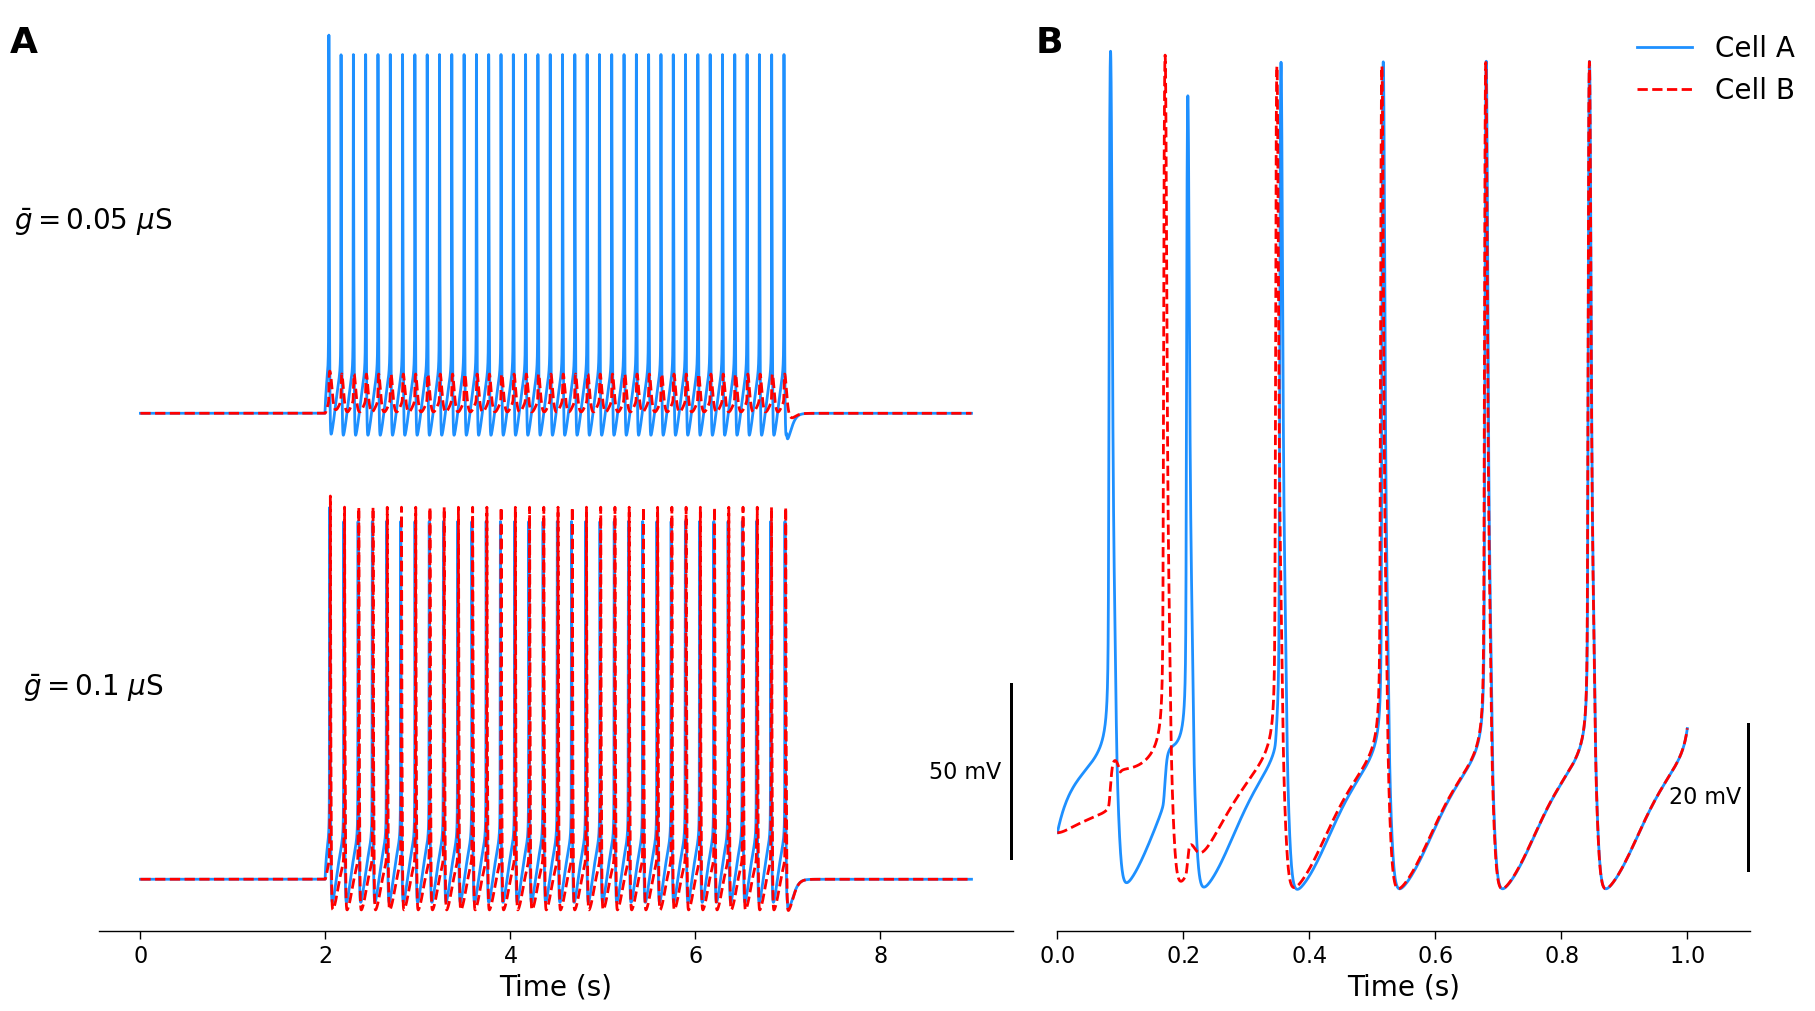

In [7]:
bw = 0.008
fig = plt.figure(figsize=(18,10),constrained_layout=True)
sfigs = fig.subfigures(1,2, width_ratios=(1.3,1))
ax1 = sfigs[0].subplots(2,1,sharey=True)
ax2 = sfigs[1].subplots(1,1,sharey=True)   

# sfigs[0].suptitle("A Stimulated",fontsize=20)
# sfigs[1].suptitle("A and B Stimulated",fontsize=20)

t1 = A1["t"]/1000
# fig,ax = plt.subplots(2,1,figsize=(14,7),constrained_layout=True)
ax1[0].plot(t1,A1["V"],color="dodgerblue",label="Cell A")
ax1[0].plot(t1,B1["V"],color="red",label="Cell B",linestyle="dashed")
ax1[0].set_ylabel(r"$\bar{g}=0.05$ $\mu$S",rotation=0,fontsize=20)
ax1[0].set_yticks([-60,-30,0,30])
remove_axes(ax1[0],remove_x=True,remove_y=True)

t2 = A2["t"]/1000
ax1[1].plot(t2,A2["V"],color="dodgerblue",label="Cell A")
ax1[1].plot(t2,B2["V"],color="red",label="Cell B",linestyle="dashed")
ax1[1].set_xlabel("Time (s)",fontsize=20)
ax1[1].set_ylabel(r"$\bar{g}=0.1$ $\mu$S",rotation=0,fontsize=20)
ax1[1].set_yticks([-60,-30,0,30])
remove_axes(ax1[1],remove_x=False,remove_y=True)
plot_vertical_scalebar(ax1[1],scalebar_length=50,bar_width=0.03,xoffset=0.1,yoffset=20)

# ax1[0].legend(fontsize=20)

t2 = A3["t"]/1000
ind = np.where((t2 >= 2) & (t2 <= 3))[0]
# fig,ax = plt.subplots(1,1,figsize=(14,7),constrained_layout=True)
ax2.plot(t2[ind]-t2[ind[0]],A3["V"][ind],color="dodgerblue",label="Cell A")
ax2.plot(t2[ind]-t2[ind[0]],B3["V"][ind],color="red",label="Cell B",linestyle="dashed")
# ax.set_ylabel("g=0.04 uS",rotation=0)
ax2.set_yticks([-60,-30,0,30])
remove_axes(ax2,remove_x=False,remove_y=True)
ax2.set_xlim((0,1.1))
# ax2.legend()
plot_vertical_scalebar(ax2,scalebar_length=20,bar_width=0.006,xoffset=0.009,yoffset=8,offset=0)
ax2.set_xlabel("Time (s)",fontsize=20)
sfigs[0].align_ylabels()

ax2.legend(fontsize=20,loc="upper right",bbox_to_anchor=(1.1,1),frameon=False)

sfig_labels = ['A', 'B']

for subfig, label in zip(sfigs, sfig_labels):
    # Add label to the upper left of each subfigure
    subfig.suptitle(label, x=0.0, y=0.98, ha='left', va='top', fontsize=26, fontweight='bold')
    
fig.savefig(os.path.join(figpath,f"{fig_prefix}_es.jpg"),bbox_inches="tight",dpi=300)